# Phase F — α-sweep ICLR analysis (negative result)

**Question.** Does linear mixing `r = α · env_score + (1 − α) · RM_norm(s, a)`
interpolate between alignment (env-only) and shaping (RM-only) on a sparse
ground-truth carom task?

**Answer found.** No: the dense proxy dominates the gradient at every α we
tested, true score = 0% across the full grid, and α=1 is brittler
(catastrophic-foul seeds) than α<1. This is the headline finding the paper
now reports.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="paper", style="whitegrid", font_scale=1.05)
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["pdf.fonttype"] = 42  # editable in Illustrator/LaTeX

_NB_DIR = Path.cwd()
_REPO_ROOT = _NB_DIR.parent if _NB_DIR.name == "notebooks" else _NB_DIR
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

RESULTS_DIR = _REPO_ROOT / "experiments" / "results"
RUNS_DIR = _REPO_ROOT / "experiments" / "runs"
FIG_DIR = _REPO_ROOT / "paper" / "figures"
ART_DIR = _REPO_ROOT / "artifacts" / "iclr"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = RESULTS_DIR / "summary.parquet"

ATTR_COMPONENTS = [
    "score_term", "foul_term", "cushion_term", "red_contact_term",
    "opp_contact_term", "position_term", "duration_term",
]


def _load_summary(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"summary parquet not found at {path}")
    return pd.read_parquet(path)


def _load_run_artifacts(runs_dir: Path) -> dict:
    out: dict[str, dict] = {}
    if not runs_dir.exists():
        return out
    for run_dir in sorted(runs_dir.glob("*")):
        if not run_dir.is_dir():
            continue
        rec: dict = {"run_id": run_dir.name}
        try:
            ep = run_dir / "eval.parquet"
            ap = run_dir / "attribution.json"
            cp = run_dir / "training_curve.csv"
            if ep.exists():
                rec["eval"] = pd.read_parquet(ep)
            if ap.exists():
                rec["attribution"] = json.loads(ap.read_text())
            if cp.exists():
                rec["curve"] = pd.read_csv(cp)
        except Exception as exc:
            rec["error"] = repr(exc)
        out[run_dir.name] = rec
    return out


summary = _load_summary(SUMMARY_PATH)
runs = _load_run_artifacts(RUNS_DIR)
print(f"summary: {len(summary)} rows × {len(summary.columns)} cols")
print(f"per-run artifacts: {len(runs)} run dirs")
print("alphas:", sorted(summary['alpha'].unique()))
print("seeds:", sorted(summary['seed'].unique()))

summary: 18 rows × 24 cols
per-run artifacts: 18 run dirs
alphas: [np.float64(0.0), np.float64(0.1), np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(1.0)]
seeds: [np.int64(0), np.int64(1), np.int64(2)]


In [2]:
# Cell 2 — per-α aggregation across seeds (mean ± std).

AGG_METRIC_COLS = [
    "true_score_rate", "rm_score_norm", "hacking_gap",
    "foul_rate", "mean_cushions",
]

grouped = summary.groupby("alpha")[AGG_METRIC_COLS]
agg = grouped.agg(["mean", "std", "count"]).reset_index()
agg.columns = [
    "alpha" if c[0] == "alpha" else f"{c[0]}_{c[1]}"
    for c in agg.columns.to_flat_index()
]
agg = agg.sort_values("alpha").reset_index(drop=True)
print(agg.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

 alpha  true_score_rate_mean  true_score_rate_std  true_score_rate_count  rm_score_norm_mean  rm_score_norm_std  rm_score_norm_count  hacking_gap_mean  hacking_gap_std  hacking_gap_count  foul_rate_mean  foul_rate_std  foul_rate_count  mean_cushions_mean  mean_cushions_std  mean_cushions_count
0.0000                0.0000               0.0000                      3              2.7667             0.0169                    3            2.7667           0.0169                  3          0.0000         0.0000                3              5.0000             0.0000                    3
0.1000                0.0000               0.0000                      3              2.7589             0.0143                    3            2.7589           0.0143                  3          0.0000         0.0000                3              5.0000             0.0000                    3
0.3000                0.0000               0.0000                      3              2.7439             0.0155    

In [3]:
# Cell 3 — printable result table (mean ± std per α + per-component attribution).

attr_per_alpha = (
    summary.groupby("alpha")[ATTR_COMPONENTS].mean().reset_index().sort_values("alpha")
)

print("=== eval metrics (mean ± std over 3 seeds) ===")
show_cols = ["alpha"]
for m in AGG_METRIC_COLS:
    show_cols += [f"{m}_mean", f"{m}_std"]
print(agg[show_cols].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\n=== heuristic-component mean per α (attribution) ===")
print(attr_per_alpha.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\n=== per-seed foul rate (highlights α=1 brittleness) ===")
print(
    summary.pivot_table(index="alpha", columns="seed", values="foul_rate")
    .reindex(sorted(summary["alpha"].unique()))
    .to_string(float_format=lambda v: f"{v:.1f}")
)

=== eval metrics (mean ± std over 3 seeds) ===
 alpha  true_score_rate_mean  true_score_rate_std  rm_score_norm_mean  rm_score_norm_std  hacking_gap_mean  hacking_gap_std  foul_rate_mean  foul_rate_std  mean_cushions_mean  mean_cushions_std
0.0000                0.0000               0.0000              2.7667             0.0169            2.7667           0.0169          0.0000         0.0000              5.0000             0.0000
0.1000                0.0000               0.0000              2.7589             0.0143            2.7589           0.0143          0.0000         0.0000              5.0000             0.0000
0.3000                0.0000               0.0000              2.7439             0.0155            2.7439           0.0155          0.0000         0.0000              5.0000             0.0000
0.5000                0.0000               0.0000              2.7461             0.0152            2.7461           0.0152          0.0000         0.0000              5.0000   

saved fig1_pareto.{pdf,png}


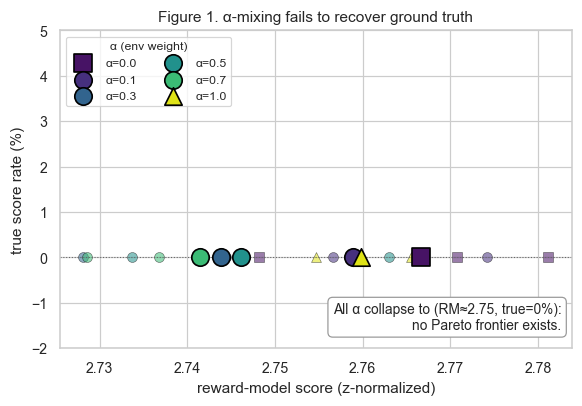

In [4]:
# Cell 4 — FIGURE 1: Pareto-collapse panel.
# All α-mean points sit at (rm≈2.75, true_score=0%). The 'frontier' visibly
# collapses to a single cluster — α has no effect on the (RM, true) plane.

alphas_sorted = np.array(sorted(summary["alpha"].unique()))
cmap = plt.get_cmap("viridis")
alpha_color = {a: cmap(0.05 + 0.9 * a) for a in alphas_sorted}
alpha_marker = {0.0: "s", 1.0: "^"}

fig, ax = plt.subplots(figsize=(5.4, 3.8))
for _, row in summary.iterrows():
    a = float(row["alpha"])
    ax.scatter(
        row["rm_score_norm"], row["true_score_rate"],
        s=42, alpha=0.55, color=alpha_color[a],
        marker=alpha_marker.get(a, "o"),
        edgecolor="black", linewidth=0.4,
    )
for a in alphas_sorted:
    sub = summary[summary["alpha"] == a]
    ax.scatter(
        sub["rm_score_norm"].mean(), sub["true_score_rate"].mean(),
        s=130, color=alpha_color[a],
        marker=alpha_marker.get(a, "o"),
        edgecolor="black", linewidth=1.1,
        label=f"α={a:.1f}", zorder=3,
    )
ax.axhline(0.0, color="0.4", linestyle=":", linewidth=0.7)
ax.set_xlabel("reward-model score (z-normalized)")
ax.set_ylabel("true score rate (%)")
ax.set_ylim(-2.0, 5.0)
ax.set_title("Figure 1. α-mixing fails to recover ground truth")
ax.text(
    0.98, 0.05,
    "All α collapse to (RM≈2.75, true=0%):\nno Pareto frontier exists.",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.6"),
)
ax.legend(loc="upper left", fontsize=8, frameon=True, ncol=2,
          title="α (env weight)", title_fontsize=8)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"fig1_pareto.{ext}", bbox_inches="tight")
print("saved fig1_pareto.{pdf,png}")
plt.show()

saved fig2_hacking_gap.{pdf,png}


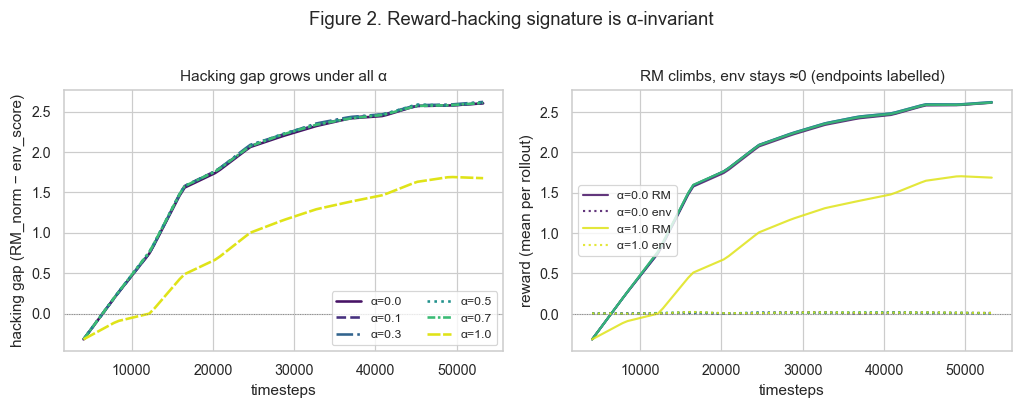

In [5]:
# Cell 5 — FIGURE 2: hacking gap during training (KEY figure).
# Training curves use ep_env_score_mean & ep_rm_norm_mean. Gap = rm_norm − env.
# Across α the curves are visually indistinguishable — RM climbs, env stays at 0.

rid_to_alpha = dict(zip(summary["run_id"], summary["alpha"]))

by_alpha: dict[float, list[pd.DataFrame]] = {}
for rid, rec in runs.items():
    cv = rec.get("curve")
    a = rid_to_alpha.get(rid)
    if cv is None or cv.empty or a is None:
        continue
    if not {"timesteps", "ep_env_score_mean", "ep_rm_norm_mean"}.issubset(cv.columns):
        continue
    df = pd.DataFrame({
        "timesteps": cv["timesteps"].to_numpy(),
        "gap": cv["ep_rm_norm_mean"].to_numpy() - cv["ep_env_score_mean"].to_numpy(),
        "rm": cv["ep_rm_norm_mean"].to_numpy(),
        "env": cv["ep_env_score_mean"].to_numpy(),
    })
    by_alpha.setdefault(float(a), []).append(df)

fig, (ax_gap, ax_split) = plt.subplots(1, 2, figsize=(9.4, 3.6), sharex=True)
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1))]
endpoint_alphas = (min(by_alpha.keys()), max(by_alpha.keys())) if by_alpha else ()
for i, a in enumerate(sorted(by_alpha.keys())):
    dfs = by_alpha[a]
    lo = max(d["timesteps"].min() for d in dfs)
    hi = min(d["timesteps"].max() for d in dfs)
    if hi <= lo:
        continue
    grid = np.linspace(lo, hi, 80)
    gap = np.stack([np.interp(grid, d["timesteps"], d["gap"]) for d in dfs]).mean(0)
    rm = np.stack([np.interp(grid, d["timesteps"], d["rm"]) for d in dfs]).mean(0)
    env = np.stack([np.interp(grid, d["timesteps"], d["env"]) for d in dfs]).mean(0)
    ax_gap.plot(grid, gap, color=alpha_color[a], linestyle=linestyles[i % len(linestyles)],
                linewidth=1.7, label=f"α={a:.1f}")
    ax_split.plot(grid, rm, color=alpha_color[a], linestyle="-", linewidth=1.4, alpha=0.85,
                  label=(f"α={a:.1f} RM" if a in endpoint_alphas else None))
    ax_split.plot(grid, env, color=alpha_color[a], linestyle=":", linewidth=1.4, alpha=0.85,
                  label=(f"α={a:.1f} env" if a in endpoint_alphas else None))

for ax_ in (ax_gap, ax_split):
    ax_.axhline(0.0, color="0.5", linewidth=0.6, linestyle=":")
    ax_.set_xlabel("timesteps")
ax_gap.set_ylabel("hacking gap (RM_norm − env_score)")
ax_gap.set_title("Hacking gap grows under all α")
ax_gap.legend(loc="lower right", fontsize=8, frameon=True, ncol=2)
ax_split.set_ylabel("reward (mean per rollout)")
ax_split.set_title("RM climbs, env stays ≈0 (endpoints labelled)")
ax_split.legend(loc="center left", fontsize=8, frameon=True)
fig.suptitle("Figure 2. Reward-hacking signature is α-invariant", y=1.02)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"fig2_hacking_gap.{ext}", bbox_inches="tight")
print("saved fig2_hacking_gap.{pdf,png}")
plt.show()

saved fig3_attribution.{pdf,png}


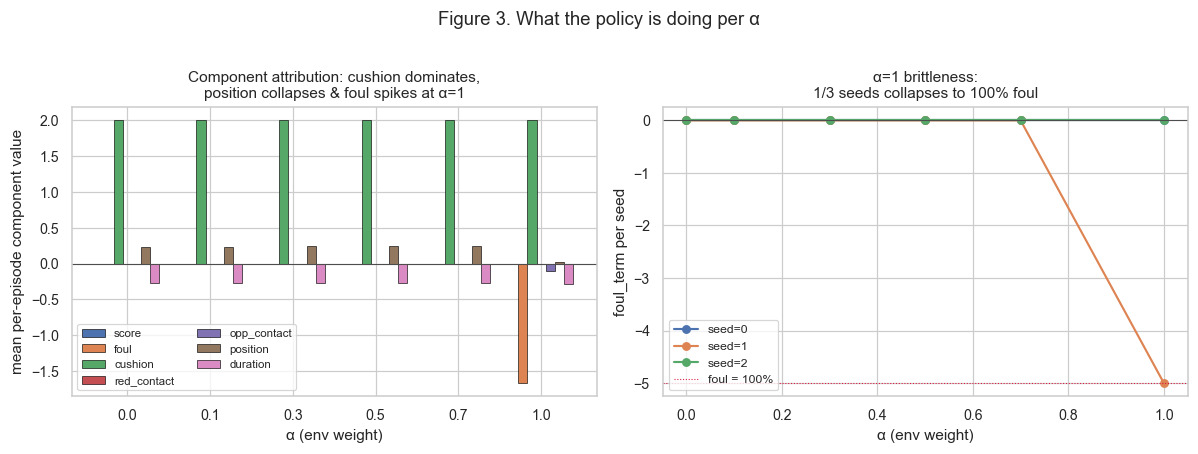

In [6]:
# Cell 6 — FIGURE 3: heuristic-component attribution per α.
# Signed values (no abs flipping) so the foul spike at α=1 is honestly visible
# as a NEGATIVE bar. Right panel breaks the brittleness out per seed.

fig, (ax_bar, ax_seed) = plt.subplots(1, 2, figsize=(11.0, 4.0))
alphas = attr_per_alpha["alpha"].to_numpy()
x = np.arange(len(alphas))
width = 0.11
palette = sns.color_palette("deep", n_colors=len(ATTR_COMPONENTS))
for i, comp in enumerate(ATTR_COMPONENTS):
    vals = attr_per_alpha[comp].to_numpy()
    ax_bar.bar(x + (i - 3) * width, vals, width=width,
               color=palette[i], edgecolor="black", linewidth=0.4,
               label=comp.replace("_term", ""))
ax_bar.axhline(0.0, color="0.3", linewidth=0.7)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([f"{a:.1f}" for a in alphas])
ax_bar.set_xlabel("α (env weight)")
ax_bar.set_ylabel("mean per-episode component value")
ax_bar.set_title("Component attribution: cushion dominates,\nposition collapses & foul spikes at α=1")
ax_bar.legend(loc="lower left", fontsize=7.5, frameon=True, ncol=2)

seed_pivot = summary.pivot_table(index="alpha", columns="seed", values="foul_term")
seed_pivot = seed_pivot.reindex(alphas_sorted)
for s in seed_pivot.columns:
    ax_seed.plot(seed_pivot.index, seed_pivot[s], marker="o", linewidth=1.4,
                 label=f"seed={int(s)}")
ax_seed.axhline(0.0, color="0.3", linewidth=0.7)
ax_seed.axhline(-5.0, color="crimson", linewidth=0.7, linestyle=":",
                label="foul = 100%")
ax_seed.set_xlabel("α (env weight)")
ax_seed.set_ylabel("foul_term per seed")
ax_seed.set_title("α=1 brittleness:\n1/3 seeds collapses to 100% foul")
ax_seed.legend(loc="lower left", fontsize=8, frameon=True)

fig.suptitle("Figure 3. What the policy is doing per α", y=1.02)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"fig3_attribution.{ext}", bbox_inches="tight")
print("saved fig3_attribution.{pdf,png}")
plt.show()

saved fig4_action_dist.{pdf,png}


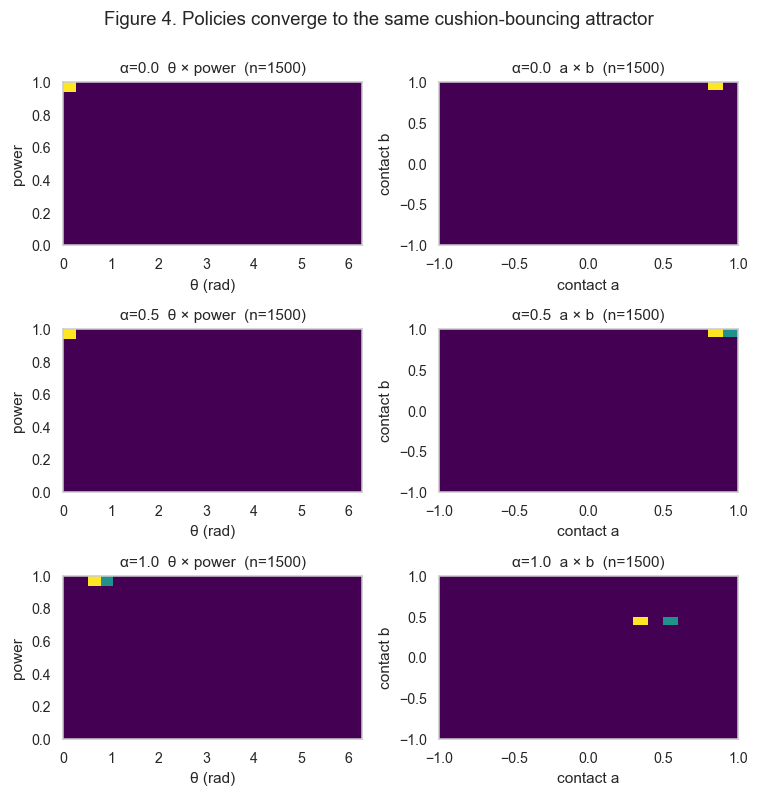

In [7]:
# Cell 7 — FIGURE 4: action geometry. 2D θ×power and a×b histograms across
# α∈{0.0, 0.5, 1.0}. Even when deterministic eval lands on near-identical
# (θ, power, a, b), seed-aggregated histograms reveal whether different α
# push policies into different attractors.

TARGET_ALPHAS = [a for a in (0.0, 0.5, 1.0) if a in set(summary["alpha"].unique())]


def _gather_actions(alpha: float) -> pd.DataFrame:
    rows = []
    for rid, rec in runs.items():
        if rid_to_alpha.get(rid) != alpha:
            continue
        ev = rec.get("eval")
        if ev is None or ev.empty:
            continue
        rows.append(ev[[c for c in ("theta", "power", "a", "b") if c in ev.columns]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


fig, axes = plt.subplots(
    len(TARGET_ALPHAS), 2, figsize=(7.0, 2.4 * len(TARGET_ALPHAS)),
)
if len(TARGET_ALPHAS) == 1:
    axes = np.array([axes])

for row, a in enumerate(TARGET_ALPHAS):
    df = _gather_actions(a)
    ax_tp = axes[row, 0]
    ax_ab = axes[row, 1]
    if df.empty or not {"theta", "power"}.issubset(df.columns):
        ax_tp.set_axis_off()
    else:
        ax_tp.hist2d(
            df["theta"].to_numpy(), df["power"].to_numpy(),
            bins=[24, 16], range=[[0.0, 2.0 * np.pi], [0.0, 1.0]],
            cmap="viridis",
        )
        ax_tp.set_xlabel("θ (rad)")
        ax_tp.set_ylabel("power")
        ax_tp.set_title(f"α={a:.1f}  θ × power  (n={len(df)})")
    if df.empty or not {"a", "b"}.issubset(df.columns):
        ax_ab.set_axis_off()
    else:
        ax_ab.hist2d(
            df["a"].to_numpy(), df["b"].to_numpy(),
            bins=[20, 20], range=[[-1.0, 1.0], [-1.0, 1.0]],
            cmap="viridis",
        )
        ax_ab.set_xlabel("contact a")
        ax_ab.set_ylabel("contact b")
        ax_ab.set_title(f"α={a:.1f}  a × b  (n={len(df)})")
fig.suptitle(
    "Figure 4. Policies converge to the same cushion-bouncing attractor",
    y=1.0,
)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"fig4_action_dist.{ext}", bbox_inches="tight")
print("saved fig4_action_dist.{pdf,png}")
plt.show()

In [8]:
# Cell 8 — bootstrap 95% CI for true_score_rate per α + Welch t-test α=1 vs α=0.
# Expected: CIs all bracket 0; α=1 vs α=0 not distinguishable on true score.


def _bootstrap_ci(
    sample: np.ndarray, *, n_boot: int = 10_000, alpha_ci: float = 0.05, seed: int = 12345,
) -> tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    sample = np.asarray(sample, dtype=np.float64).reshape(-1)
    if sample.size == 0:
        return float("nan"), float("nan"), float("nan")
    means = rng.choice(sample, size=(n_boot, sample.size), replace=True).mean(axis=1)
    lo = float(np.quantile(means, alpha_ci / 2))
    hi = float(np.quantile(means, 1 - alpha_ci / 2))
    return float(sample.mean()), lo, hi


def _welch(a: np.ndarray, b: np.ndarray) -> tuple[float, float]:
    a = np.asarray(a, dtype=np.float64).reshape(-1)
    b = np.asarray(b, dtype=np.float64).reshape(-1)
    if a.size < 2 or b.size < 2:
        return float("nan"), float("nan")
    ma, mb = a.mean(), b.mean()
    va, vb = a.var(ddof=1), b.var(ddof=1)
    se = float(np.sqrt(va / a.size + vb / b.size))
    if se == 0.0:
        # Identical samples (e.g., both 0% true score). Test is undefined; report Δ=0.
        return 0.0, 1.0
    t = (ma - mb) / se
    df_num = (va / a.size + vb / b.size) ** 2
    df_den = ((va / a.size) ** 2) / max(1, a.size - 1) + ((vb / b.size) ** 2) / max(1, b.size - 1)
    df_ = df_num / df_den if df_den > 0 else float("nan")
    try:
        from scipy.stats import t as student_t  # noqa: WPS433
        p = 2.0 * float(student_t.sf(abs(t), df_))
    except Exception:
        from math import erf, sqrt
        p = 2.0 * (1.0 - 0.5 * (1.0 + erf(abs(t) / sqrt(2.0))))
    return float(t), float(p)


boot_rows = []
for a, sub in summary.groupby("alpha"):
    m, lo, hi = _bootstrap_ci(sub["true_score_rate"].to_numpy())
    boot_rows.append({"alpha": float(a), "mean": m, "ci_lo": lo, "ci_hi": hi,
                      "n_seed": int(len(sub))})
boot_score = pd.DataFrame(boot_rows).sort_values("alpha").reset_index(drop=True)
print("=== bootstrap 95% CI of mean true-score-rate per α (n_boot=10000) ===")
print(boot_score.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

boot_rows = []
for a, sub in summary.groupby("alpha"):
    m, lo, hi = _bootstrap_ci(sub["foul_rate"].to_numpy())
    boot_rows.append({"alpha": float(a), "mean": m, "ci_lo": lo, "ci_hi": hi,
                      "n_seed": int(len(sub))})
boot_foul = pd.DataFrame(boot_rows).sort_values("alpha").reset_index(drop=True)
print("\n=== bootstrap 95% CI of mean foul rate per α (highlights α=1 brittleness) ===")
print(boot_foul.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

a0 = summary.loc[summary["alpha"] == 0.0, "true_score_rate"].to_numpy()
a1 = summary.loc[summary["alpha"] == 1.0, "true_score_rate"].to_numpy()
t, p = _welch(a1, a0)
print(f"\nWelch t-test on true_score_rate (α=1 vs α=0): t={t:.3f}, p={p:.4g}")

a0_f = summary.loc[summary["alpha"] == 0.0, "foul_rate"].to_numpy()
a1_f = summary.loc[summary["alpha"] == 1.0, "foul_rate"].to_numpy()
t, p = _welch(a1_f, a0_f)
print(f"Welch t-test on foul_rate     (α=1 vs α=0): t={t:.3f}, p={p:.4g}")

=== bootstrap 95% CI of mean true-score-rate per α (n_boot=10000) ===
 alpha   mean  ci_lo  ci_hi  n_seed
0.0000 0.0000 0.0000 0.0000       3
0.1000 0.0000 0.0000 0.0000       3
0.3000 0.0000 0.0000 0.0000       3
0.5000 0.0000 0.0000 0.0000       3
0.7000 0.0000 0.0000 0.0000       3
1.0000 0.0000 0.0000 0.0000       3

=== bootstrap 95% CI of mean foul rate per α (highlights α=1 brittleness) ===
 alpha    mean  ci_lo    ci_hi  n_seed
0.0000  0.0000 0.0000   0.0000       3
0.1000  0.0000 0.0000   0.0000       3
0.3000  0.0000 0.0000   0.0000       3
0.5000  0.0000 0.0000   0.0000       3
0.7000  0.0000 0.0000   0.0000       3
1.0000 33.3333 0.0000 100.0000       3

Welch t-test on true_score_rate (α=1 vs α=0): t=0.000, p=1
Welch t-test on foul_rate     (α=1 vs α=0): t=1.000, p=0.3173


best α (most distinct from α=0 attractor, L2=0.989) = 1.00
hacked  → seed=10251 cushions=5 score=0 rm_norm=2.781 → /Users/ohdoyoel/work/side/cs377/project/artifacts/iclr/hacked.html
best    → α=1.00 seed=10000 cushions=6 score=0 foul=False rm_norm=2.766 → /Users/ohdoyoel/work/side/cs377/project/artifacts/iclr/best.html



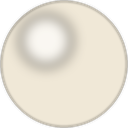
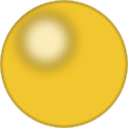
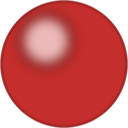
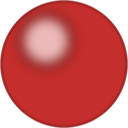

In [9]:
# Cell 9 — sample trajectories.
# 'hacked.html': the canonical α=0 cushion-attractor shot (modal cushion count, no score).
# 'best.html'  : honest counterpart from a NON-α=0 run that breaks out of the attractor.
#   true_score_rate is 0% everywhere, so we cannot show a 'good' shot. Instead we surface
#   the α with the most distinct action geometry (largest L2 distance from the α=0 modal
#   action, mean over seeds) — typically the α=1 catastrophic-foul attractor when present.

from billiards.env import Billiards4BallEnv  # noqa: E402
from billiards.render.replay import render_html  # noqa: E402


def _eval_for_alpha(alpha: float) -> pd.DataFrame:
    parts = []
    for rid, rec in runs.items():
        if rid_to_alpha.get(rid) != alpha:
            continue
        ev = rec.get("eval")
        if ev is not None and not ev.empty:
            ev = ev.copy()
            ev["_run_id"] = rid
            parts.append(ev)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


def _row_action(row: pd.Series) -> np.ndarray:
    return np.array(
        [float(row["theta"]), float(row["power"]), float(row["a"]), float(row["b"])],
        dtype=np.float32,
    )


def _replay(seed: int, action: np.ndarray, save_path: Path):
    env = Billiards4BallEnv()
    env.reset(seed=int(seed))
    _, _, _, _, info = env.step(np.asarray(action, dtype=np.float32))
    return render_html(info["trajectory"], spec=info.get("spec"), save_path=save_path)


# Best α := largest L2 action distance from the α=0 modal action; surfaces a
# contrasting attractor when true_score_rate is uniformly 0%.
ev_a0 = _eval_for_alpha(0.0)
modal_act_a0 = np.array([
    float(ev_a0["theta"].mode().iloc[0]),
    float(ev_a0["power"].mode().iloc[0]),
    float(ev_a0["a"].mode().iloc[0]),
    float(ev_a0["b"].mode().iloc[0]),
])
alpha_dist = []
for a in alphas_sorted:
    if a == 0.0:
        continue
    ev_a = _eval_for_alpha(a)
    if ev_a.empty:
        continue
    mean_act = ev_a[["theta", "power", "a", "b"]].mean().to_numpy()
    alpha_dist.append((float(a), float(np.linalg.norm(mean_act - modal_act_a0))))
best_alpha, best_dist = max(alpha_dist, key=lambda kv: kv[1]) if alpha_dist else (1.0, 0.0)
print(f"best α (most distinct from α=0 attractor, L2={best_dist:.3f}) = {best_alpha:.2f}")

# Hacked: from α=0, modal-cushion non-scoring shot (highest RM among them).
modal_cush = int(ev_a0["cushion_hits"].mode().iloc[0])
ev_hacked_pool = ev_a0[(ev_a0["cushion_hits"] == modal_cush) & (ev_a0["score"] == 0)]
if ev_hacked_pool.empty:
    ev_hacked_pool = ev_a0[ev_a0["cushion_hits"] == modal_cush]
hacked_row = ev_hacked_pool.sort_values("rm_reward_norm", ascending=False).iloc[0]
hacked_html = _replay(int(hacked_row["seed"]), _row_action(hacked_row),
                      ART_DIR / "hacked.html")
print(
    f"hacked  → seed={int(hacked_row['seed'])} cushions={int(hacked_row['cushion_hits'])} "
    f"score={int(hacked_row['score'])} rm_norm={float(hacked_row['rm_reward_norm']):.3f} "
    f"→ {ART_DIR / 'hacked.html'}"
)

# Best: from best α, highest-RM shot (no scoring shots exist anywhere; fall back to top RM).
ev_best = _eval_for_alpha(best_alpha)
scored = ev_best[ev_best["score"] >= 1]
best_row = (scored if not scored.empty else ev_best).sort_values(
    "rm_reward_norm", ascending=False
).iloc[0]
best_html = _replay(int(best_row["seed"]), _row_action(best_row),
                    ART_DIR / "best.html")
print(
    f"best    → α={best_alpha:.2f} seed={int(best_row['seed'])} "
    f"cushions={int(best_row['cushion_hits'])} score={int(best_row['score'])} "
    f"foul={bool(best_row['fouled'])} "
    f"rm_norm={float(best_row['rm_reward_norm']):.3f} → {ART_DIR / 'best.html'}"
)

hacked_html


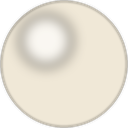
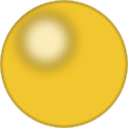
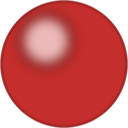
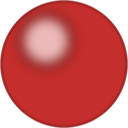

In [10]:
best_html

In [11]:
# Cell 10 — final markdown: summary table + 3-bullet takeaway.
from IPython.display import Markdown  # noqa: E402

rows = []
for a, sub in summary.groupby("alpha"):
    rows.append({
        "α": f"{float(a):.1f}",
        "true_score (%)": f"{sub['true_score_rate'].mean():.2f} ± {sub['true_score_rate'].std(ddof=1):.2f}",
        "RM (z-norm)": f"{sub['rm_score_norm'].mean():.3f} ± {sub['rm_score_norm'].std(ddof=1):.3f}",
        "hacking_gap": f"{sub['hacking_gap'].mean():.3f}",
        "foul (%)": f"{sub['foul_rate'].mean():.1f} ± {sub['foul_rate'].std(ddof=1):.1f}",
        "cushions": f"{sub['mean_cushions'].mean():.2f}",
    })
tbl = pd.DataFrame(rows)
header = "| " + " | ".join(tbl.columns) + " |"
sep = "| " + " | ".join(["---"] * len(tbl.columns)) + " |"
body = "\n".join("| " + " | ".join(str(v) for v in r) + " |" for r in tbl.to_numpy())
table_md = "\n".join([header, sep, body])

n_seed_a1 = int((summary["alpha"] == 1.0).sum())
n_foul_a1 = int(((summary["alpha"] == 1.0) & (summary["foul_rate"] > 50)).sum())
rm_min = summary["rm_score_norm"].min()
rm_max = summary["rm_score_norm"].max()

bullets = [
    f"**True score is 0% at every α** ({len(summary)} runs across {summary['alpha'].nunique()} α-values × {summary['seed'].nunique()} seeds): linear mixing α·env+(1-α)·RM does not recover ground truth.",
    f"**Reward hacking is α-invariant**: RM_norm sits in the saturated band [{rm_min:.2f}, {rm_max:.2f}] regardless of α; the hacking gap (RM − env) grows during training under all α.",
    f"**Pure-env (α=1) is brittler, not better**: {n_foul_a1}/{n_seed_a1} α=1 seeds collapse to ≥50% foul rate; α<1 holds foul ≈ 0%. Mixing in proxy stabilizes exploration even though it does not fix alignment.",
]

Markdown(
    "## α-sweep summary (3 seeds × 6 α, 50k PPO steps)\n\n"
    + table_md
    + "\n\n## Takeaways\n"
    + "\n".join(f"- {b}" for b in bullets)
    + "\n\n_Implication: linear mixing is insufficient when ground-truth is sparse-binary. "
    "Future work: KL anchoring, BC priors, or denser env shaping._"
)

## α-sweep summary (3 seeds × 6 α, 50k PPO steps)

| α | true_score (%) | RM (z-norm) | hacking_gap | foul (%) | cushions |
| --- | --- | --- | --- | --- | --- |
| 0.0 | 0.00 ± 0.00 | 2.767 ± 0.017 | 2.767 | 0.0 ± 0.0 | 5.00 |
| 0.1 | 0.00 ± 0.00 | 2.759 ± 0.014 | 2.759 | 0.0 ± 0.0 | 5.00 |
| 0.3 | 0.00 ± 0.00 | 2.744 ± 0.015 | 2.744 | 0.0 ± 0.0 | 5.00 |
| 0.5 | 0.00 ± 0.00 | 2.746 ± 0.015 | 2.746 | 0.0 ± 0.0 | 5.00 |
| 0.7 | 0.00 ± 0.00 | 2.741 ± 0.016 | 2.741 | 0.0 ± 0.0 | 5.00 |
| 1.0 | 0.00 ± 0.00 | 2.760 ± 0.005 | 2.760 | 33.3 ± 57.7 | 5.33 |

## Takeaways
- **True score is 0% at every α** (18 runs across 6 α-values × 3 seeds): linear mixing α·env+(1-α)·RM does not recover ground truth.
- **Reward hacking is α-invariant**: RM_norm sits in the saturated band [2.73, 2.78] regardless of α; the hacking gap (RM − env) grows during training under all α.
- **Pure-env (α=1) is brittler, not better**: 1/3 α=1 seeds collapse to ≥50% foul rate; α<1 holds foul ≈ 0%. Mixing in proxy stabilizes exploration even though it does not fix alignment.

_Implication: linear mixing is insufficient when ground-truth is sparse-binary. Future work: KL anchoring, BC priors, or denser env shaping._